# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the libraries
from PIL import Image, ImageOps
import numpy as np
from IPython.display import display

Original image size: (512, 512)


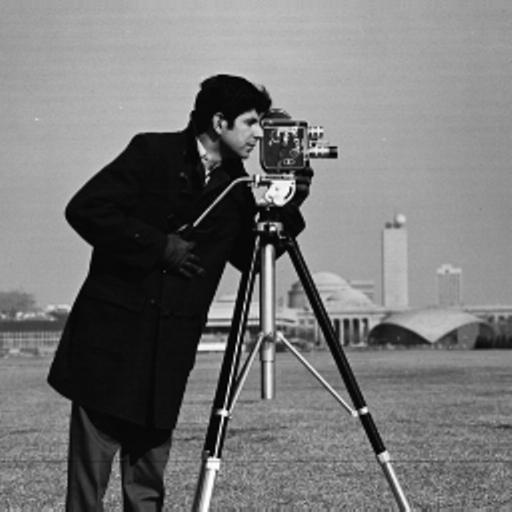

In [2]:
# ── Load image ────────────────────────────────────
img = Image.open("input_image.jpg").convert("L")
print("Original image size:", img.size)
display(img)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
width, height = img.size
print("Original size:", (width, height))

# scaling factors
cx = 2
cy = 2
new_width = int(width * cx)
new_height = int(height * cy)
print("New size:", (new_width, new_height))

Original size: (512, 512)
New size: (1024, 1024)


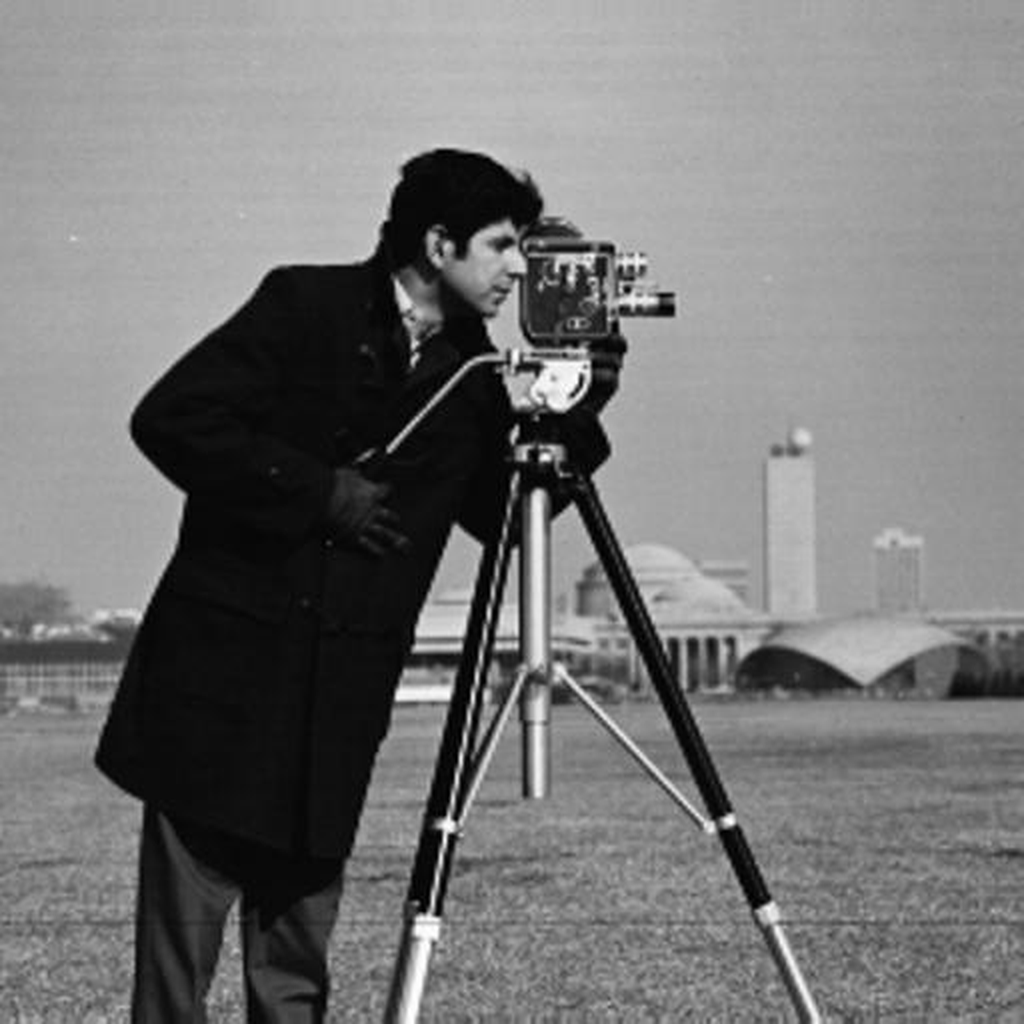

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method with high-quality LANCZOS resampling
scaled_img = img.resize(
    (new_width, new_height),
    resample=Image.Resampling.LANCZOS
)

display(scaled_img)

In [5]:
# Save the scaled image and print the sizes
# The new image name should be "task1_1_scaled.jpg"
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size  :", scaled_img.size)
print("Saved as task1_1_scaled.jpg")

Original size: (512, 512)
Scaled size  : (1024, 1024)
Saved as task1_1_scaled.jpg


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
# Non-uniform scale: cx = 2, cy = 1
cx_nonuniform = 2
cy_nonuniform = 1

nonuniform_size = (
    int(width * cx_nonuniform),
    int(height * cy_nonuniform)
)

print("Non-uniform target size:", nonuniform_size)

Non-uniform target size: (1024, 512)


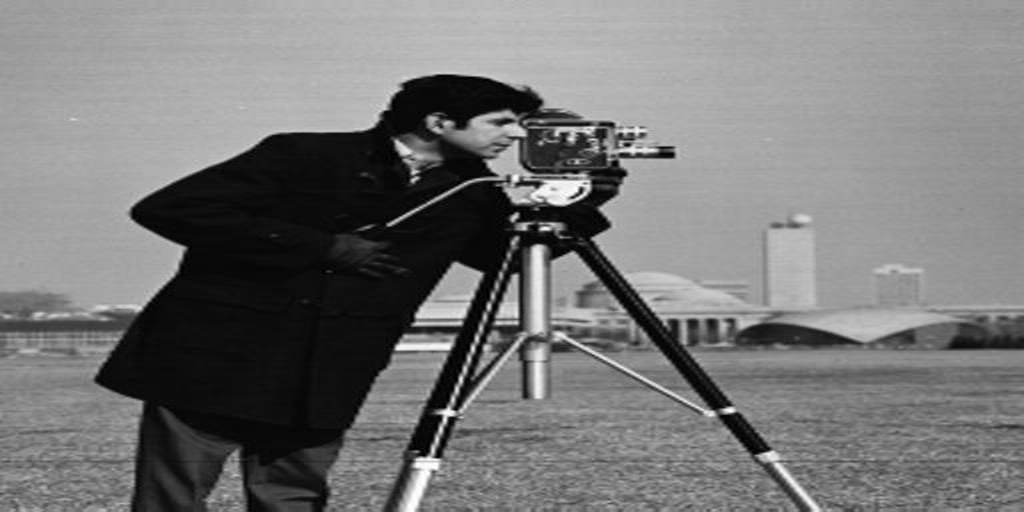

In [7]:
# Stretch horizontally only
nonuniform_img = img.resize(
    nonuniform_size,
    resample=Image.Resampling.LANCZOS
)

display(nonuniform_img)

In [8]:
# Save the non-uniformly scaled image
nonuniform_img.save("task1_1_nonuniform.jpg")

print("Original size   :", img.size)
print("Non-uniform size:", nonuniform_img.size)
print("Saved as task1_1_nonuniform.jpg")

Original size   : (512, 512)
Non-uniform size: (1024, 512)
Saved as task1_1_nonuniform.jpg


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size : (700, 700)
Saved as task1_2_rotated.jpg


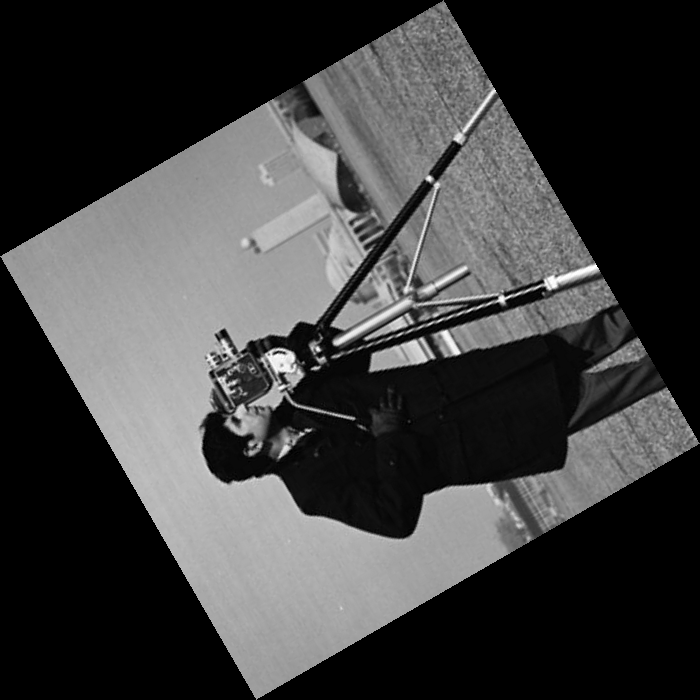

In [9]:
# ── 2. Rotate 120 degrees ──────────────────────────
# expand=True keeps the full rotated image inside the new canvas
rotated_img = img.rotate(
    120,
    resample=Image.Resampling.BICUBIC,
    expand=True,
    fillcolor=0
)

rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size :", rotated_img.size)
print("Saved as task1_2_rotated.jpg")
display(rotated_img)

### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size
print("Image dimensions:", (width, height))

Image dimensions: (512, 512)


In [11]:
# -- d. Define the shear matrix ──────────────────────────
# X-axis shear with factor 0.5
shx = 0.5
shy = 0.0

# Increase canvas width so the sheared image is not cropped
new_width_shear = int(width + abs(shx) * height)
new_height_shear = int(height + abs(shy) * width)

print("Shear factors (shx, shy):", (shx, shy))
print("Sheared canvas size:", (new_width_shear, new_height_shear))

Shear factors (shx, shy): (0.5, 0.0)
Sheared canvas size: (768, 512)


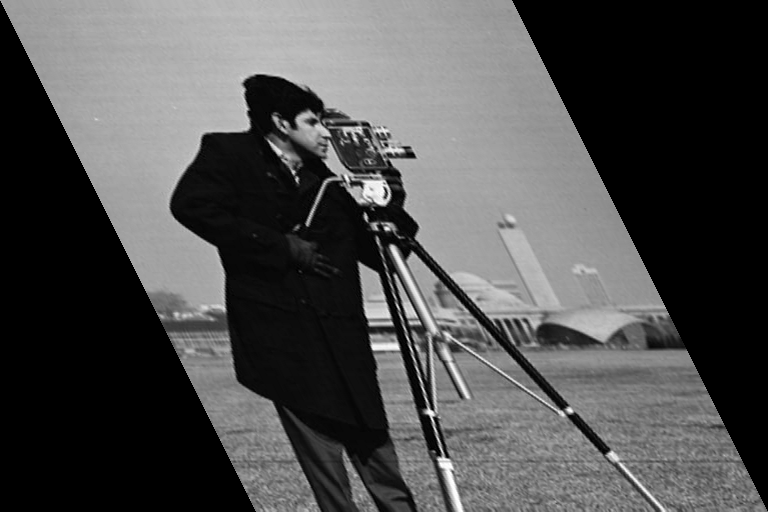

In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# Forward X-shear: x' = x + shx*y
# PIL transform() expects the inverse mapping, therefore b = -shx.
sheared_img = img.transform(
    (new_width_shear, new_height_shear),
    Image.Transform.AFFINE,
    (1, -shx, 0, -shy, 1, 0),
    resample=Image.Resampling.BICUBIC,
    fillcolor=0
)

display(sheared_img)

In [13]:
# -- f. Save the sheared image
# The new image name should be "task1_3_sheared.jpg"
sheared_img.save("task1_3_sheared.jpg")

print("Original size:", img.size)
print("Sheared size :", sheared_img.size)
print("Saved as task1_3_sheared.jpg")

Original size: (512, 512)
Sheared size : (768, 512)
Saved as task1_3_sheared.jpg


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

X-shear 0.1: size=(563, 512), saved=experiment_x_shear_0.1.jpg
X-shear 0.3: size=(665, 512), saved=experiment_x_shear_0.3.jpg
X-shear 0.8: size=(921, 512), saved=experiment_x_shear_0.8.jpg
Y-shear 0.5: (512, 768) saved=experiment_y_shear_0.5.jpg


Combined X/Y shear: (665, 665) saved=experiment_xy_shear_0.3.jpg


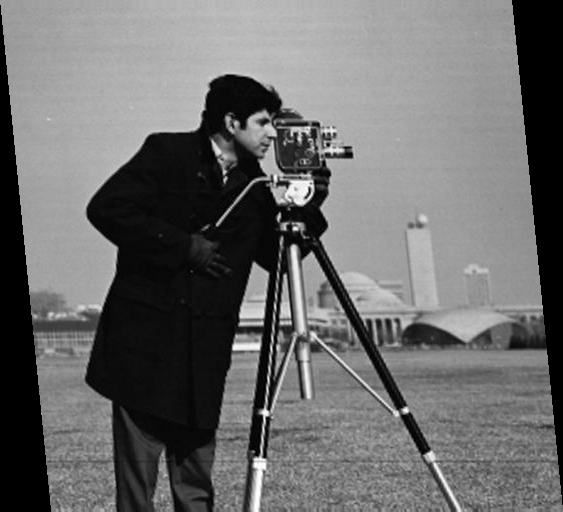

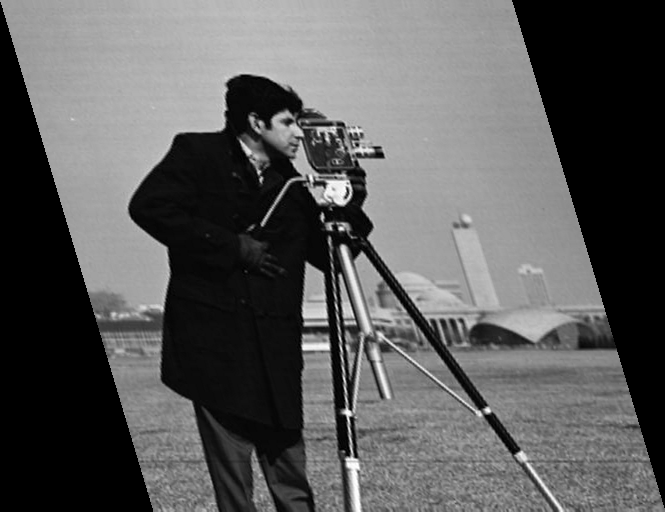

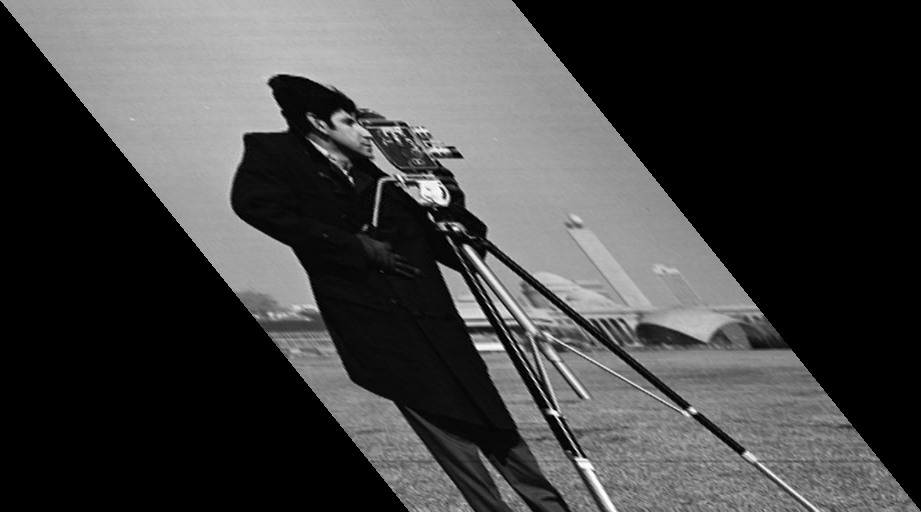

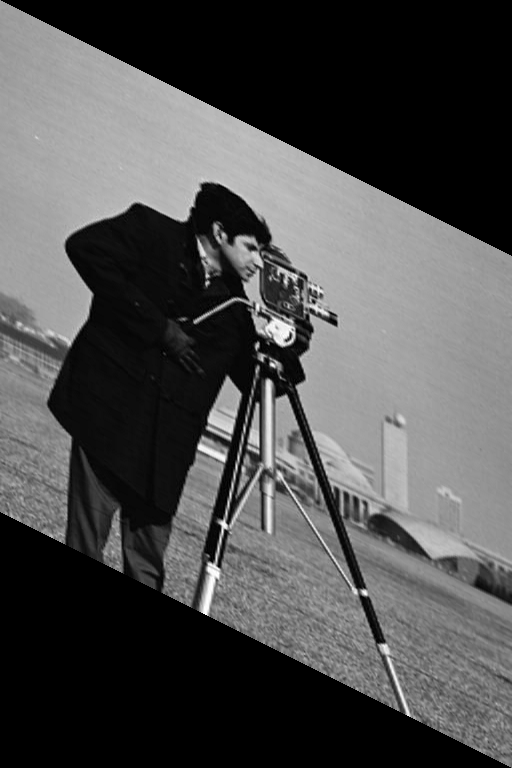

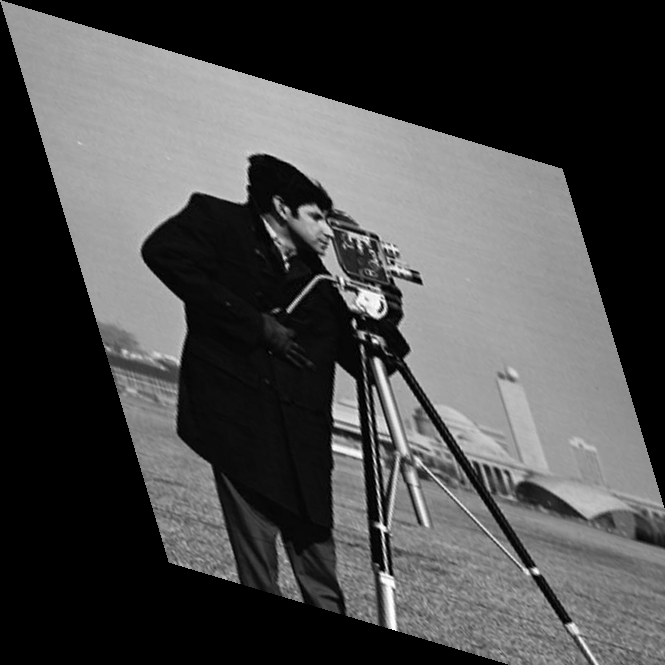

In [14]:
# ── Shear experiments and comparison ─────────────────────
def x_shear(image, factor):
    w, h = image.size
    out_w = int(w + abs(factor) * h)
    return image.transform(
        (out_w, h),
        Image.Transform.AFFINE,
        (1, -factor, 0, 0, 1, 0),
        resample=Image.Resampling.BICUBIC,
        fillcolor=0
    )

# Compare X-axis shear factors 0.1, 0.3, and 0.8
for factor in [0.1, 0.3, 0.8]:
    result = x_shear(img, factor)
    filename = f"experiment_x_shear_{factor}.jpg"
    result.save(filename)
    print(f"X-shear {factor}: size={result.size}, saved={filename}")

# Y-axis shear (factor 0.5)
shy_exp = 0.5
y_canvas = (width, int(height + abs(shy_exp) * width))
y_sheared = img.transform(
    y_canvas,
    Image.Transform.AFFINE,
    (1, 0, 0, -shy_exp, 1, 0),
    resample=Image.Resampling.BICUBIC,
    fillcolor=0
)
y_sheared.save("experiment_y_shear_0.5.jpg")
print("Y-shear 0.5:", y_sheared.size, "saved=experiment_y_shear_0.5.jpg")

# Combined X and Y shear in one affine matrix
shx_combined, shy_combined = 0.3, 0.3
combined_canvas = (
    int(width + abs(shx_combined) * height),
    int(height + abs(shy_combined) * width)
)
combined_shear = img.transform(
    combined_canvas,
    Image.Transform.AFFINE,
    (1, -shx_combined, 0, -shy_combined, 1, 0),
    resample=Image.Resampling.BICUBIC,
    fillcolor=0
)
combined_shear.save("experiment_xy_shear_0.3.jpg")
print("Combined X/Y shear:", combined_shear.size, "saved=experiment_xy_shear_0.3.jpg")

display(x_shear(img, 0.1))
display(x_shear(img, 0.3))
display(x_shear(img, 0.8))
display(y_sheared)
display(combined_shear)

# Intensity Transformations
Negative · Log · Power Law (Gamma)

Saved as task2_1_negative_numpy.jpg


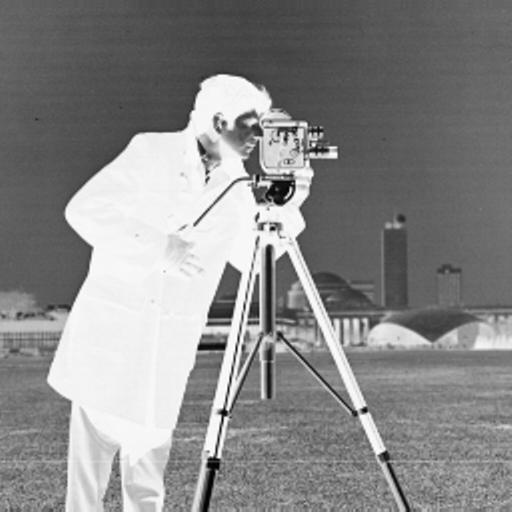

In [15]:
# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
arr = np.array(img, dtype=np.uint8)
negative_arr = 255 - arr
negative_numpy = Image.fromarray(negative_arr)

negative_numpy.save("task2_1_negative_numpy.jpg")
print("Saved as task2_1_negative_numpy.jpg")
display(negative_numpy)

Saved as task2_1_negative_pil.jpg
Methods are identical: True


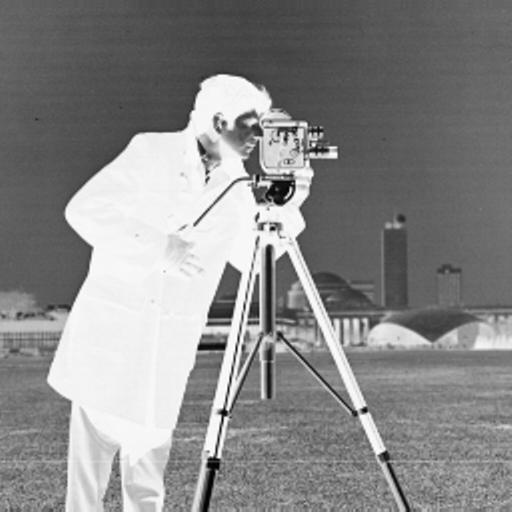

In [16]:
# Method 2: PIL's ImageOps
negative_pil = ImageOps.invert(img)

negative_pil.save("task2_1_negative_pil.jpg")
print("Saved as task2_1_negative_pil.jpg")

# Verify that both negative methods give the same pixel values
print("Methods are identical:", np.array_equal(np.array(negative_numpy), np.array(negative_pil)))
display(negative_pil)

c = 45.98590442833571
Saved as task2_2_log.jpg


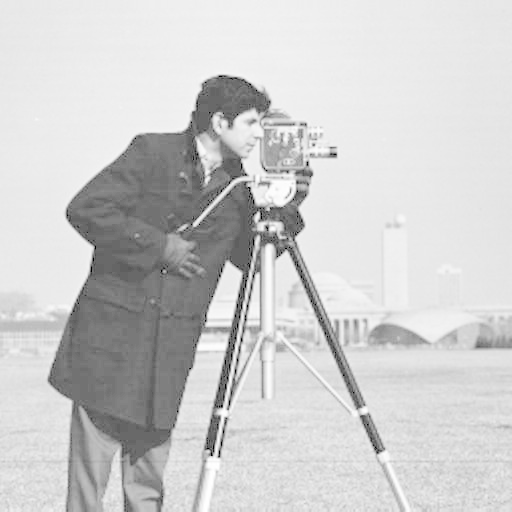

In [17]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r)
# Choose c so that r=255 maps to s=255:
# c = 255 / log(1 + 255)
c = 255 / np.log(1 + 255)

# IMPORTANT: convert to float first to avoid uint8 overflow in (1 + r)
arr_float = np.array(img, dtype=np.float32)

# Apply the log transformation to each pixel
log_arr = c * np.log1p(arr_float)
log_arr = np.clip(log_arr, 0, 255).astype(np.uint8)
log_transformed_img = Image.fromarray(log_arr)

log_transformed_img.save("task2_2_log.jpg")
print("c =", c)
print("Saved as task2_2_log.jpg")
display(log_transformed_img)

In [18]:
# ── 3. Power-law / Gamma correction ───────────────
# s = 255 * (r / 255)^gamma
arr_norm = np.array(img, dtype=np.float32) / 255.0

gamma_bright = 0.5
gamma_dark = 2.0

gamma_bright_arr = 255 * np.power(arr_norm, gamma_bright)
gamma_dark_arr = 255 * np.power(arr_norm, gamma_dark)

gamma_bright_img = Image.fromarray(
    np.clip(gamma_bright_arr, 0, 255).astype(np.uint8)
)
gamma_dark_img = Image.fromarray(
    np.clip(gamma_dark_arr, 0, 255).astype(np.uint8)
)

gamma_bright_img.save("task2_3_gamma_0.5.jpg")
gamma_dark_img.save("task2_3_gamma_2.0.jpg")

print("Saved as task2_3_gamma_0.5.jpg  (gamma < 1: brighter)")
print("Saved as task2_3_gamma_2.0.jpg  (gamma > 1: darker)")

Saved as task2_3_gamma_0.5.jpg  (gamma < 1: brighter)
Saved as task2_3_gamma_2.0.jpg  (gamma > 1: darker)


Original


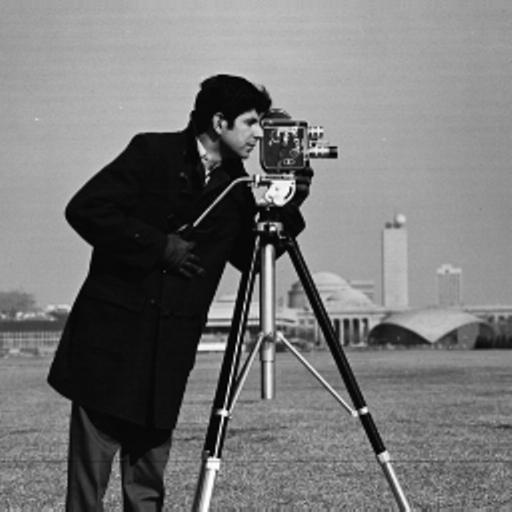

Gamma = 0.5 (brighter)


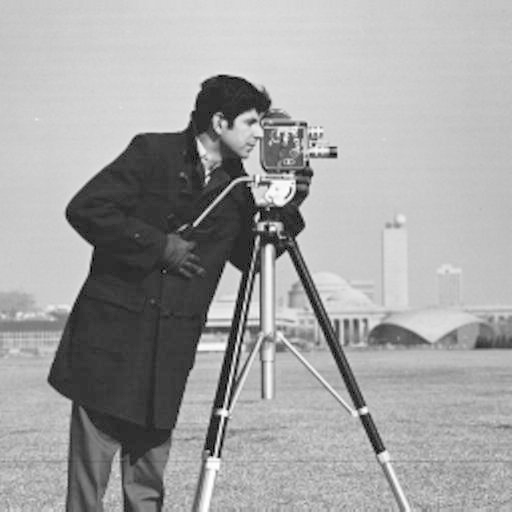

Gamma = 2.0 (darker)


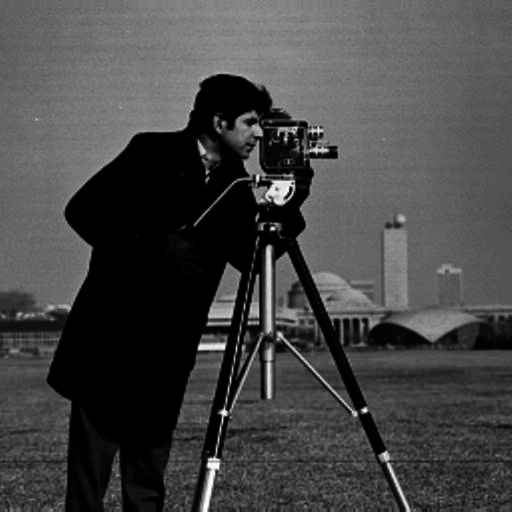

In [19]:
# Display gamma results for comparison
print("Original")
display(img)

print("Gamma = 0.5 (brighter)")
display(gamma_bright_img)

print("Gamma = 2.0 (darker)")
display(gamma_dark_img)